In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import re
from math import ceil
from matplotlib.colors import Normalize
import gseapy as gp
 
def enrichr_analysis(gene_list, gene_set='GO_Biological_Process_2023', organism='mouse'):
    """Perform Enrichr analysis and return filtered results."""
    try:
        enrichr_results = gp.enrichr(
            gene_list=gene_list,
            gene_sets=gene_set,
            organism=organism
        )
        enrichr_df = enrichr_results.results
    except Exception as e:
        print(f"Enrichr analysis failed: {e}")
        return None
   
    # Adjust p-values and filter significant terms
    pval_threshold = 0.05
    enrichr_df = enrichr_df[enrichr_df['Adjusted P-value'] <= pval_threshold]
   
    return enrichr_df[['Term', 'Adjusted P-value', 'Genes']]


In [3]:
fname = "qubo_features.txt"
gl1 = pd.read_csv(fname, sep='\t', header=None)[0].tolist()
fname = r"lasso_features.txt"
gl2 = pd.read_csv(fname, sep='\t', header=None)[0].tolist()

In [4]:
df1 = enrichr_analysis(gl1)
df1['Term'] = [i.split(' (')[0] for i in df1['Term']]
df1 = df1[df1['Adjusted P-value'] < 0.05].copy()
print(df1.shape)
df1.head()

(38, 3)


,Term,Adjusted P-value,Genes
0,Regulation Of Apoptotic Process,0.000013,TOP2A;HSP90AA1;ANXA1;CITED2;IGFBP3;WNT5A;FSTL1...
1,Epithelial Cell Differentiation,0.000185,GSTK1;LGALS3;KRT19;PCNA;ANXA1;KRT17;KRT13;FSTL1
2,Positive Regulation By Host Of Viral Process,0.000504,EEF1A1;KRT17;CFL1;NUCKS1
3,Epithelial Cell Migration,0.023186,ANLN;S100A2;CYP1B1;FSTL1
4,Epithelium Development,0.023518,GSTK1;LGALS3;KRT19;PCNA;KRT17;KRT13


In [5]:
All_gl = [i.split(";") for i in df1['Genes']]
all_genes = []
for i in All_gl:
    for j in i:
        all_genes.append(j)
all_genes[0:3]

pathway_gene_df = pd.DataFrame(np.zeros([df1.shape[0],len(all_genes)]), index= df1.Term,columns=all_genes)
pathway_gene_df.shape

for i in range(df1.shape[0]):
    for gene in df1['Genes'].iloc[i].split(";"):
        pathway_gene_df.loc[df1.Term.iloc[i],gene] = 1

In [6]:
import seaborn as sns
sns.clustermap(pathway_gene_df, cmap='viridis', figsize=(16, 10), col_cluster=False)

ModuleNotFoundError: No module named 'seaborn'

(38, 38)


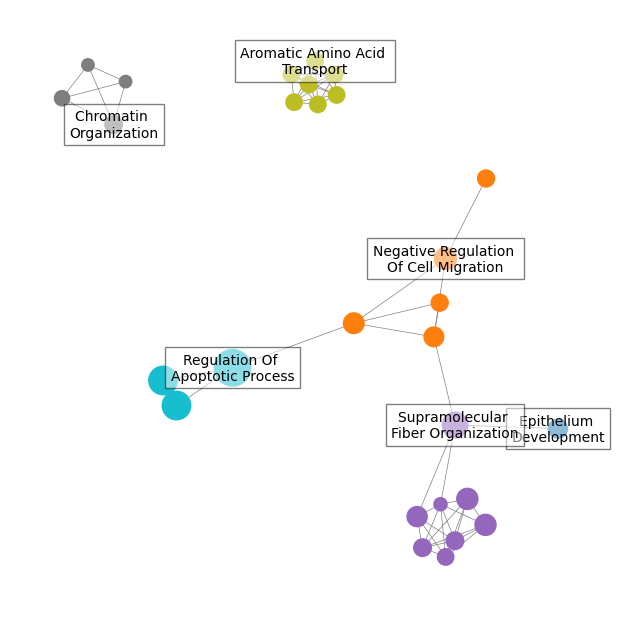

In [195]:
A = np.corrcoef(pathway_gene_df)
np.fill_diagonal(A, 0)
print(A.shape)
Pathnet = pd.DataFrame(A, columns=pathway_gene_df.index, index=pathway_gene_df.index)
Pathnet[Pathnet < 0.3] = 0

PathGraph = nx.from_pandas_adjacency(Pathnet)
partition = nx.community.louvain_communities(PathGraph, resolution=1, seed=42)
nx.set_node_attributes(PathGraph, partition, 'group')
nx.set_node_attributes(PathGraph, dict(zip(pathway_gene_df.index, pathway_gene_df.sum(axis=1))), 'ngenes')
PathGraph

# Filter clusters to keep only those with more than 1 nodes
filtered_partition = [community for community in partition if len(community) > 1]

# Update color_map based on filtered_partition
color_map = []
for node in PathGraph:
    for i, community in enumerate(filtered_partition):
        if node in community:
            color_map.append(i)
            break
    else:
        color_map.append(-1)  # Assign a default color for nodes not in any community

# Filter nodes with more than 2 links
nodes_to_plot = [node for node, degree in PathGraph.degree() if degree > 1]

# Create a subgraph with the filtered nodes
subgraph = PathGraph.subgraph(nodes_to_plot)

# Update color_map for the subgraph
subgraph_color_map = [color_map[list(PathGraph.nodes()).index(node)] for node in subgraph.nodes()]

# Set the layout with a higher k value to prevent subgraphs from flying apart
pos = nx.fruchterman_reingold_layout(subgraph, seed=42, k=0.3)

plt.figure(figsize=(6, 6))

# Function to wrap text labels without breaking words
def wrap_label(label, width=20):
    words = label.split()
    wrapped_label = ''
    line = ''
    for word in words:
        if len(line) + len(word) + 1 <= width:
            line += (word + ' ')
        else:
            wrapped_label += (line + '\n')
            line = word + ' '
    wrapped_label += line
    return wrapped_label.strip()

# Update labels to be wrapped
labels = {node: wrap_label(node) for node in subgraph.nodes()}

# Draw the graph with repelled labels and edge weights
node_sizes = [PathGraph.nodes[node]['ngenes'] * 10 for node in subgraph.nodes()]  # Scale node size by number of genes
nx.draw(subgraph, pos=pos, node_size=node_sizes, font_size=10,
    node_color=subgraph_color_map, edge_color='gray', font_color='black',
    font_weight='bold', width=0.5, alpha=1, cmap=plt.cm.tab10)

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(subgraph, 'weight')

# Find the largest node by number of genes in each cluster
largest_nodes = {}
for node in subgraph.nodes():
    cluster = subgraph_color_map[list(subgraph.nodes()).index(node)]
    if cluster not in largest_nodes or PathGraph.nodes[node]['ngenes'] > PathGraph.nodes[largest_nodes[cluster]]['ngenes']:
        largest_nodes[cluster] = node

# Adjust label positions to repel them, only for the largest nodes
for node, coords in pos.items():
    if node in largest_nodes.values():
        x, y = coords
        plt.text(x, y, labels[node], fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

plt.show()